<a href="https://colab.research.google.com/github/shivansh2310/Quantitative-Portfolio-Management/blob/main/Risk_%26_Random_Matrix_Theory_(Chapter_6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### A. The Marchenko-Pastur (MP) Distribution
If you create a matrix of completely random, uncorrelated stock returns and run Principal Component Analysis (PCA) on it, the eigenvalues (which represent the variance of each factor) will not be zero. They will form a predictable mathematical curve called the Marchenko-Pastur distribution.

* The MFE Insight: Any eigenvalue in your real stock market data that falls inside this theoretical random curve is statistically indistinguishable from pure noise.

### B. Eigenvalue Clipping
To build an institutional risk model, we:

1. Run PCA on our stock returns to get the eigenvalues.

2. Calculate the theoretical MP maximum bound for pure noise.

3. Keep the large eigenvalues (these are real structural factors, like the Market and Sectors).

4. Clip all the small eigenvalues that fall below the MP bound, setting them to an average constant.

5. Reconstruct the covariance matrix. The noise is mathematically erased.

## RMT Covariance Filter

In [18]:
import pandas as pd
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [19]:
universe = {
    'AAPL': 'Tech', 'MSFT': 'Tech', 'NVDA': 'Tech', 'AMD': 'Tech', 'ORCL': 'Tech',
    'JPM': 'Fin', 'BAC': 'Fin', 'GS': 'Fin', 'MS': 'Fin', 'C': 'Fin',
    'XOM': 'Energy', 'CVX': 'Energy', 'COP': 'Energy', 'EOG': 'Energy', 'SLB': 'Energy',
    'JNJ': 'Health', 'UNH': 'Health', 'PFE': 'Health', 'ABBV': 'Health', 'MRK': 'Health'
}
tickers = list(universe.keys())

print("Fetching historical data... (Takes ~10 seconds)")
# Fetch 1 year of daily close prices
prices = yf.download(tickers, period="1y")['Close']
prices = prices[tickers] # Ensure column order

raw_returns = prices.pct_change()
raw_returns.head()

[                       0%                       ]

Fetching historical data... (Takes ~10 seconds)


[*********************100%***********************]  20 of 20 completed


Ticker,AAPL,MSFT,NVDA,AMD,ORCL,JPM,BAC,GS,MS,C,XOM,CVX,COP,EOG,SLB,JNJ,UNH,PFE,ABBV,MRK
Date,,,,,,,,,,,,,,,,,,,,
2025-06-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-06-18,0.004805,0.004602,0.009437,-0.002439,0.012921,0.016474,0.018766,0.016970,0.018680,0.012797,-0.007105,-0.004434,-0.017801,-0.006900,-0.006375,-0.010828,-0.005407,-0.005000,0.000054,0.012902
2025-06-20,0.022485,-0.005914,-0.011204,0.011436,-0.027031,0.003796,0.009765,0.008753,0.001434,0.001276,0.013340,0.009177,0.009488,0.012442,-0.000279,-0.006236,-0.016895,0.003769,-0.001024,-0.002901
2025-06-23,0.002488,0.018014,0.002225,0.010449,0.009114,0.011891,0.017582,0.009488,0.009721,0.011600,-0.025807,-0.017987,-0.031471,-0.026572,-0.058873,0.010214,-0.004404,0.002503,-0.008311,0.013914
2025-06-24,-0.005955,0.008457,0.025872,0.068298,0.039751,0.010745,0.007775,0.023544,0.014179,0.022429,-0.030428,-0.022539,-0.025297,-0.010739,-0.006819,0.005749,0.016430,0.011652,0.009741,0.001996


In [20]:
print("Preparing the Return Matrix...")
# We need the raw returns from Day 1, shaped as N assets by T days
# 'raw_returns' should be in memory from Day 1
returns_matrix = raw_returns.dropna().values
T, N = returns_matrix.shape

print(f"Matrix Dimensions: T (Days) = {T}, N (Assets) = {N}")

Preparing the Return Matrix...
Matrix Dimensions: T (Days) = 251, N (Assets) = 20


In [21]:
# Standardize returns (mean 0, variance 1) for PCA
returns_std = (returns_matrix - np.mean(returns_matrix, axis=0)) / np.std(returns_matrix, axis=0)

In [22]:
# Calculate the empirical correlation matrix
corr_matrix = np.corrcoef(returns_std, rowvar=False)

# Extract eigenvalues and eigenvectors
eigenvalues, eigenvectors = eigh(corr_matrix)

# Sort them in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

In [23]:
print("Applying Random Matrix Theory (Marchenko-Pastur)...")
# Calculate the Marchenko-Pastur maximum theoretical noise bound
q = T / N  # Ratio of time observations to assets
sigma_sq = 1.0 # Variance is 1 because we standardized
mp_max = sigma_sq * (1 + np.sqrt(1/q))**2

print(f"Marchenko-Pastur Theoretical Maximum Noise Bound: {mp_max:.4f}")

Applying Random Matrix Theory (Marchenko-Pastur)...
Marchenko-Pastur Theoretical Maximum Noise Bound: 1.6442


In [24]:
# Find how many factors are real signal (above the noise bound)
num_signals = len(eigenvalues[eigenvalues > mp_max])
print(f"Number of True Structural Factors discovered: {num_signals} out of {N}")


Number of True Structural Factors discovered: 3 out of 20


In [25]:
print("\nClipping the Noise...")
# Keep the signal eigenvalues
clipped_eigenvalues = eigenvalues.copy()

# Average the noise eigenvalues to preserve the trace (sum of variance)
noise_average = np.mean(eigenvalues[num_signals:])
clipped_eigenvalues[num_signals:] = noise_average

# Reconstruct the cleaned correlation matrix
cleaned_corr_matrix = eigenvectors @ np.diag(clipped_eigenvalues) @ eigenvectors.T

# Convert back to a covariance matrix using the original standard deviations
stds = np.std(returns_matrix, axis=0)
cleaned_cov_matrix = np.outer(stds, stds) * cleaned_corr_matrix

print("STATUS: RMT Covariance Matrix successfully reconstructed and cleaned of noise.")


Clipping the Noise...
STATUS: RMT Covariance Matrix successfully reconstructed and cleaned of noise.


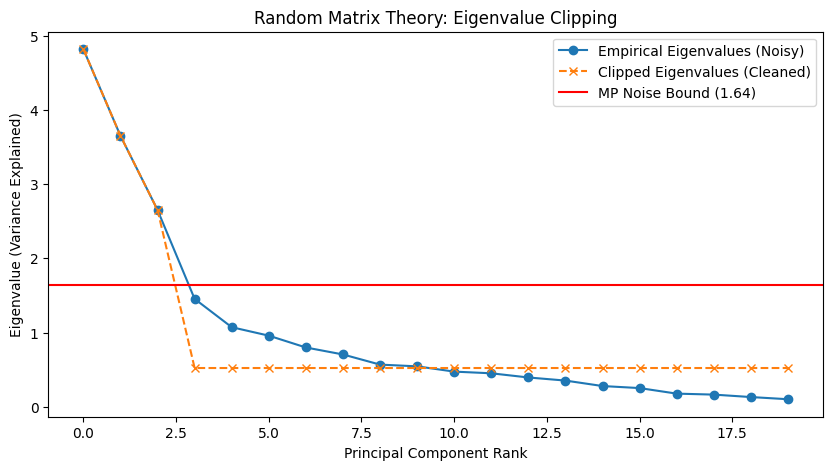

In [26]:
# Visualization
plt.figure(figsize=(10, 5))
plt.plot(eigenvalues, marker='o', label='Empirical Eigenvalues (Noisy)')
plt.plot(clipped_eigenvalues, marker='x', linestyle='--', label='Clipped Eigenvalues (Cleaned)')
plt.axhline(y=mp_max, color='r', linestyle='-', label=f'MP Noise Bound ({mp_max:.2f})')
plt.title("Random Matrix Theory: Eigenvalue Clipping")
plt.xlabel("Principal Component Rank")
plt.ylabel("Eigenvalue (Variance Explained)")
plt.legend()
plt.show()